# SETUP

Bom, ficou claro que o AE como esta só reproduz o AB3AM4 quando funcionando como uma identidade (o output aparece no input)...
Para resolver isso, pode ser interessante tirar a Normalização da rede, adicionar uma camada linear no encoder seguida de uma batch normalization... e então entra nas funcoes ReLU6 ou tanh como está... E segue com Normalização_our como está...

In [5]:
#%%capture
import xarray as xr 
import sys, os, copy, time, dask, gc
from pathlib import Path
from netCDF4 import Dataset
import importlib
import argparse
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch  
import cartopy.crs as ccrs                   # import projections
import cartopy.feature as cf                 # import features

# Path to KAE files
sys.path.insert(0, '/home/iuri/KoopmanAE')
import Variational_Model
from Variational_Model import VKAE,VLieAE
from tools import *
from SWE import *

def print_cudamem():
    print('CUDA AVAILABLE:',torch.cuda.is_available())
    if torch.cuda.is_available():
        torch.set_default_device(device)
        torch.cuda.empty_cache()
        print("torch.cuda.memory_allocated: %fGB"%(torch.cuda.memory_allocated(0)/1024/1024/1024))
        print("torch.cuda.memory_reserved: %fGB"%(torch.cuda.memory_reserved(0)/1024/1024/1024))
        print("torch.cuda.max_memory_reserved: %fGB"%(torch.cuda.max_memory_reserved(0)/1024/1024/1024))
        usage,available = torch.cuda.mem_get_info()
        print("Total memory still available for usage: %fGB"%(usage/1024/1024/1024))
        print("Total memory available: %fGB"%(available/1024/1024/1024))


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#torch.set_default_device(device)
print_cudamem()

CUDA AVAILABLE: True
torch.cuda.memory_allocated: 0.000000GB
torch.cuda.memory_reserved: 0.000000GB
torch.cuda.max_memory_reserved: 0.000000GB
Total memory still available for usage: 14.982910GB
Total memory available: 15.887939GB


# Set SWE EQUATIONS / DOMAIN / IC

Gravity wave Courant number
0.033188167252486446
Calculating dx based on given mx. dx =  200157.7794640436
Calculating dy based on given my. dy =  200157.7794640436
Gravity wave Courant number
0.0
Internal Domain shapes (u,v,h): (200, 200) (200, 200) (200, 200)


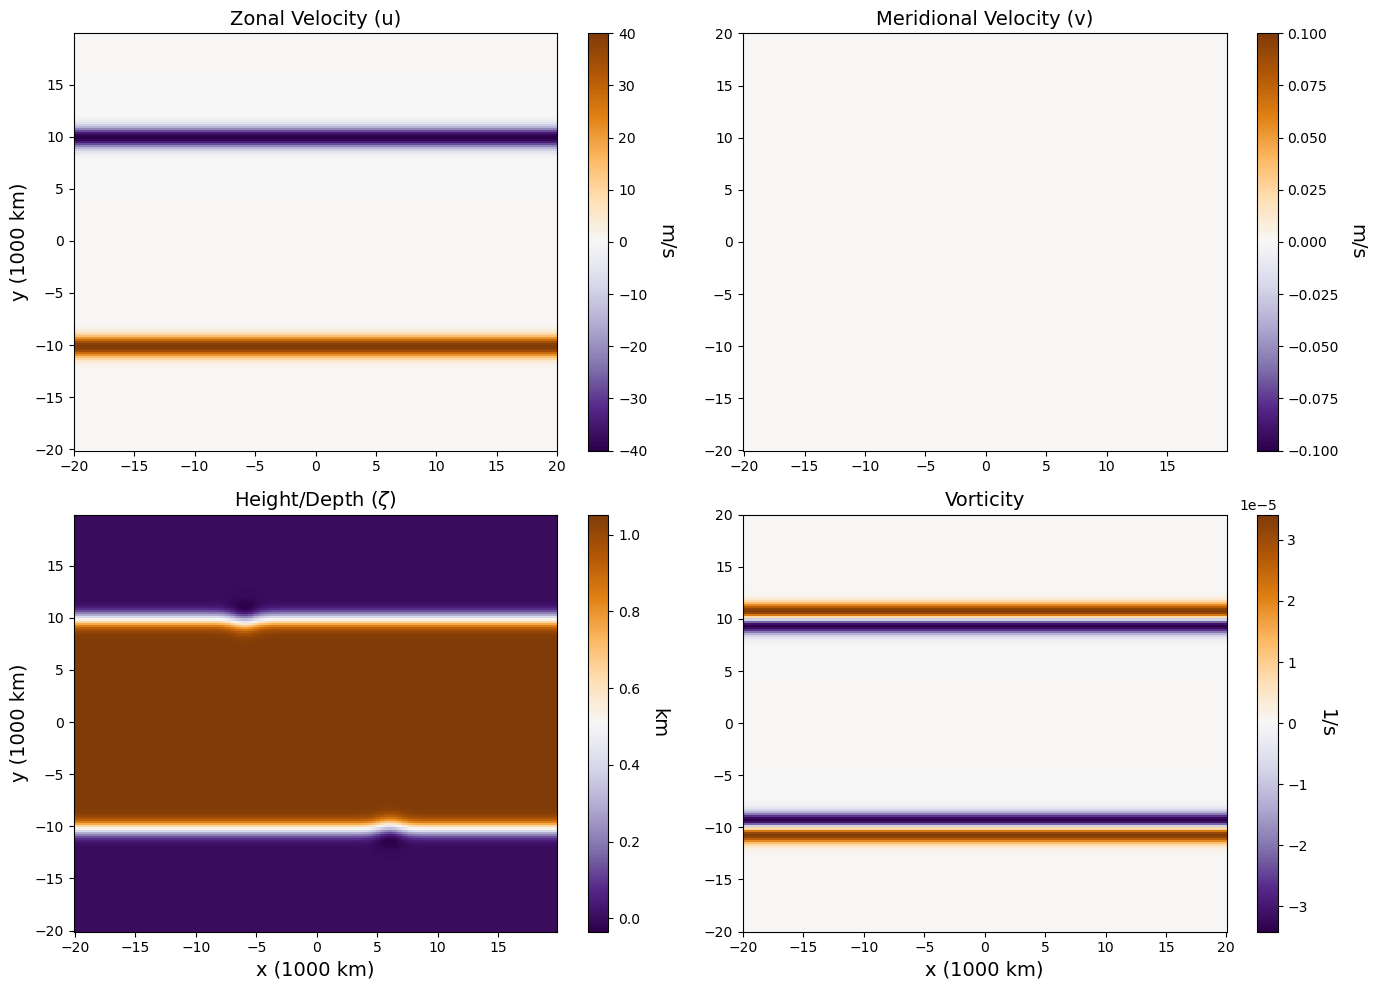

In [3]:
#%%capture
import SWE
importlib.reload(SWE)
from SWE import *
# Discrete domain construction
parameter = 1

T=12*oneday/parameter
# Shallow water 2D problem
unflip_domain = True # needs to be unfliped fpr the manual AB3AM4 algorithm
equation = "AB3AM4" # 'swe', needs Topo=0...

# DOMAIN
X = np.pi*erad/parameter
DT,XY = 360/parameter,200
dom = Domain2D(t0=0.0, T=T, xi=-X, xf=X, yi=-X,
               yf=X, dt=DT, mx=XY, my=XY,CROCO=unflip_domain)
# Unstable Jet #
hbar = 10000
f = 2.0*omega
noise_amp = 1e-6 * hbar
sw  = SWE_2D(hbar = 0, f = f, g = grav, ini = 3, dom = dom,
             random=False,noise_amp=noise_amp,Topo = hbar)

## RK3/4 needs Topo=0...
#sw  = SWE_2D(hbar = hbar, f = f, g = grav, ini = 3, dom = dom,
#            random=False,noise_amp=noise_amp,Topo = 0)

## Cossine Bell Tsunami ##
#hbar = 100 #      # ini=5
#f = 0             # ini=5
#DT,XY = 720,100   # ini = 5
#dom = Domain2D(t0=0.0, T=T, xi=-X, xf=X, yi=-X,
#               yf=X, dt=DT, mx=XY, my=XY,CROCO=unflip_domain)
#sw  = SWE_2D(hbar = hbar, f = f, g = grav, ini = 5, dom = dom,
#             random=True,noise_amp=noise_amp,Topo = 0)

# Numerical method and operators
num_met  = SWE_2D_num_method(dom = dom, sw = sw, equation = equation)
print('Internal Domain shapes (u,v,h):',sw.u0().shape,sw.v0().shape,sw.h0().shape)
# Plot initial conditions
vort0 = num_met.rel_vort(sw.u0(),sw.v0())
plot2D_panel(sw.u0(), sw.v0(), sw.h0(), vort0, dom)
plt.show()

#### AB3AM4 Integration Backward

In [ ]:
num_plots = 12
plot_ktimes = (np.arange(num_plots)/num_plots)*dom.nt
print(plot_ktimes, dom.nt)
time_int(num_met, plot_ktimes,mode='backward')

#### AB3AM4 Integration Forward

In [ ]:
num_plots = 12
plot_ktimes = (np.arange(num_plots)/num_plots)*dom.nt
print(plot_ktimes, dom.nt)
time_int(num_met, plot_ktimes,mode='forward')

# Treino da rede

#### LieAE
- A Normalização é essencial. Estou usando uma para U e outra para V.
- O output signal (+ ou -) está independente da direção temporal ('forward/backward'). Ou seja, para forward: +update, backward: -update
- SWE_CheckPoint.py tem salvo a função treino que funciona para o Input_Tensor trivial.

Trivial: modelZ e modelU com tendencias no input
semiTrivial: apenas modelU com tendencias no input

In [7]:
# Cria argsparse para guardar argumentos da rede e de seu treino
args = argparse.Namespace()

In [ ]:
### LieAE training
gc.collect()
torch.cuda.empty_cache()
import train, SWE, Variational_Model
importlib.reload(Variational_Model)
importlib.reload(SWE)
importlib.reload(train)
from train import *
from SWE import *
from Variational_Model import *

## SIMULATION VARIABLES: ##
# SSH == 0, Ubar == 1, Vbar == 2 ##
#
args.n_variables = 1 #
Epochs = 10
# Primeiro Contador # Zeta.X.n.n #
alphas  = [2] #4,8
betas   = [2] #4,8
modelosZ = ['LieAEsampleNet']
modelosU = ['LieAEsampleNet']
# Segundo contador #  Zeta.n.X.n #
bottles = [10,20] #
#Terceiro contador # Zeta.n.n.X#
alphaz = [0]
betaz = [0]

# l2 penalty to weight size.
args.wd =  1e-5 #0
for actfunc,name in zip([nn.ReLU6(),nn.Tanh()],['_dt+_ReLU6','_dt+_Tanh']):
 AE = -2 # contador de auto-encoders: -1 é alpha-4/beta-4
 for alpha, beta, modeloZ,modeloU in zip(alphas,betas,modelosZ,modelosU):
    modeloZ += name
    modeloU += name
    AE+=1
    KO = -1 # contador botles: -1 é dimensão 10
    ## PARA AJUSTAR ETAPAS DO TREINAMENTO #
    #if AE==0:                            #
    #    bottles = [20]          #
    #    KO=0 # contador de CAMADAS OCULTAS #
    #else:                                  #
    #    bottles = [10,20]         #
    ########################################
    
    for bottle in bottles:
        KO+=1
        HL=-1 # contador de CAMADAS OCULTAS: -1 é 0 hiddenlayers
        
        # PARA AJUSTAR ETAPAS DO TREINAMENTO   #
        #if KO==0 and AE==0:                    #
        #    alphaz = [1]                       #
        #    betaz = [1]                        #
        #    HL=0 # contador de CAMADAS OCULTAS #
        #else:                                  #
        #    alphaz = [0]                     #
        #    betaz = [0]                      #
        #   HL=-1                              #
        #########################################

        for alphax,betax in zip(alphaz,betaz):
            mlv = np.inf
            HL+=1

            #################
            # Cria modelo   #
            ### ### ### ### #
            
            ETAPA = 0
            
            args.alpha = alpha # camada intermediária encoder # *16
            #
            args.alphax = alphax # numero de camadas ocultas no encoder
            #
            args.beta = beta  # camada intermediária decoders # *16
            #
            args.betax = betax # numero de camadas ocultas no decoder
            #
            args.bottleneck = bottle # dimensão no espaço de Koopman
            #
            args.bottleneckx = 0 # numero de camas ocultas no espaço de Koopman
            
             ## PARAMETROS DA REDE NEURAL Antigos...
            args.n = 1 # dimensão da "convolução" na rede
            args.init_scale = 1 # constante multiplicativa da svd inicial para setar o operador linear da rede
            args.dim_out = [1,1,1] # cada decoder pode ter um numero de saidas diferente...

            ## USANDO DMD_vector no Simulator.py
            args.dim = 0 # Sem Vetores do sistema no input, apenas acrescimos. Era: 3*res_temporal # n_variaveis x res_temporal
            # args.Bdim from DMD_input_creator (NOVO): #
            u_f,v_f,h_f, u1_f,v1_f,h1_f,u2_f,v2_f,h2_f = Evolve_system(num_met,3,print=False)
            statef = [[h2_f.copy(),u2_f.copy(),v2_f.copy()],
                      [h1_f.copy(),u1_f.copy(),v1_f.copy()],
                      [ h_f.copy(), u_f.copy(), v_f.copy()]]
            IHm = np.squeeze(DMD_input_tensor(num_met,statef,0,'forward', None ).to(cpu)).mean(axis=0)
            IUm = np.squeeze(DMD_input_tensor(num_met,statef,1,'forward', None,torch.from_numpy(h2_f).to(cpu) ).to(cpu)).mean(axis=0)
            args.Bdim = IHm.shape[0]
            #################################3
            
            modelZ = VLieAE(args.dim, args.dim_out, args.n, args.Bdim, args.bottleneck,
                            args.n_variables, args.alpha,args.beta, args.alphax, args.betax, 
                            args.bottleneckx, args.init_scale, multiencoder=False,
                            multidynamics=False,ActFunc=actfunc,dropKoop=0.2,dropHidden=0.4,
                            type='B',Const = num_met.dom.dt)#,dropKoop=0.2,dropHidden=0.4
            args.NN = 'LieAE'
            #modelZ = BetaNet(args.dim, args.n, args.Bdim)
            #args.NN = 'Beta'
            
            modelZ.to(device)
            argsZ = copy.deepcopy(args)

            # Pega Momento2CROCO#
            args.Bdim = IUm.shape[0]
            argsU = copy.deepcopy(args)
            argsU.NN = 'LieAE'
            modelU = VLieAE(args.dim, args.dim_out, args.n, args.Bdim, args.bottleneck,
                            args.n_variables, args.alpha,args.beta, args.alphax, args.betax, 
                            args.bottleneckx, args.init_scale, multiencoder=False,
                            multidynamics = False, ActFunc=actfunc,dropKoop=0.2,dropHidden=0.4,
                            type='C')#,dropKoop=0.1,dropHidden=0.3
            
            modelU.to(device)
            
            # Limpa memoria do CUDA
            gc.collect()
            torch.cuda.empty_cache()
            
            print('**** Setup ****')
            print(black('Total params: %.2fM' % (sum(p.numel() for p in modelU.parameters())/1000000.0),['dim']))
            print('Total params: %.2fk' % (sum(p.numel() for p in modelU.parameters())/1000.0))
            print('************')
            #print(model)
            
            starting_epoch = 0
            n_epochs = 1
            argsZ.lr = 0.002 # era 0.002 na pinn.-1.0.0
            argsU.lr = 0.002 # era 0.001 em todas as redes anteriores a 6: Redes sem encoder Linear+batchnorm
            argsZ.lr_decay = 0.6
            argsU.lr_decay = 0.6 
            
            print(black('\n ############### Rede LieAE: a-' +str(args.alpha) + ',alpha-'+str(args.alphax) + ',K-'+str(args.bottleneck)+ ',b-' +str(args.beta)+ ',beta-' + str(args.betax) + ' ################### \n','reverse'))
            
            ETAPAS = list(range(starting_epoch, n_epochs))
            Epocas = []
            
            argsZ.folder = '/home/iuri/CROCO/Diagnostics/SingleVariableModel/3a_ordem/Sim_train/'+modeloZ+'.'+str(AE)+'.'+str(KO)+'.'+str(HL)+'/'
            
            output_file = argsZ.folder + '/train_his.html'
            output_figure = [argsZ.folder + '/train_figs/',argsZ.folder + '/val_figs/']
                                                                                                  
            # Cria Folder se não existir ainda
            if not os.path.isdir(argsZ.folder):
                os.mkdir(argsZ.folder)
            # Se não existirem ainda, cria Folder para salvar as figuras 
            if not os.path.isdir(argsZ.folder+'train_figs/'):
                os.mkdir(argsZ.folder+'train_figs/')
                os.mkdir(argsZ.folder+'val_figs/')
            
            for ETAPA in ETAPAS:
                gc.collect()
                torch.cuda.empty_cache()
                #deep_flush_cudamem(Simulador_variables[0],model)
                print('LR: ', argsZ.lr)
                #
                argsZ.epochs = Epochs #
                #
                argsZ.lr_update = [1000]#[20,40,90,140,200,300,400,501]
                #
                argsZ.lamb = 1 # 1/2 # constante multiplicativa do loss_identity - Para o Zeta era 1
                #
                argsZ.eta = 1/(bottle**2) # 1e-2, constante multiplicativa do loss_consist
                #
                argsZ.nu = 1/2 # 1/3 # constante multiplicativa do loss_bwd
                
                #
                #ETAPA=str(ETAPA)
                    
                print('#~#~#~#~#~# \n ETAPA: '+ str(ETAPA) +' \n#~#~#~#~#~#')
                modelu = str(argsZ.alpha)+'a'+str(argsZ.bottleneck)+'k'+str(argsZ.beta)+'b'
                epok= str(argsZ.epochs)+'e' # ESTA SALVO ERRADO -- 75i1000k50e provavelmente
                
                EPOCHS =[]
                modelZ,modelU,optimizer,epoch_hist,test_hist = Train_LieAE(num_met, modelZ, modelU, argsZ, argsU, # train_steps=[100,240] no trivial5.1
                                                                           epochs=argsZ.epochs, train_steps=[10,20],val_step=20, #train_steps=[1,5,50,100,240]
                                                                           train_time=3500, validation_time=500, Normalize = True,
                                                                           output_file=output_file,output_figure=output_figure)
    
            # Limpa gradientes antes de começar o treino do proximo modelo
            gc.collect()
            torch.cuda.empty_cache()
            #deep_flush_cudamem(Simulador_variables[0],model)

            # LIMPA MEMORIA DA MAQUINA VIRTUAL
            del modelZ, modelU, optimizer, epoch_hist, test_hist

Gravity wave Courant number
0.033188167252486446
dimensao do vetor de entrada na rede =  36
Const 360.0
dimensao do vetor de entrada na rede =  6
**** Setup ****
Total params: 0.00M
Total params: 3.44k
************

 ############### Rede LieAE: a-2,alpha-0,K-10,b-2,beta-0 ################### 

LR:  0.002
#~#~#~#~#~# 
 ETAPA: 0 
#~#~#~#~#~#
LieAE Training 2.0  ( with pinn )
Start Normalization ( with mask )
Input vectors without Normalization, batchnorm needed.
Ordem de diferença das variaveis Zeta e Momento: 100.0
Start Training


#### MLP

In [ ]:
# Cria argsparse para guardar argumentos da rede e de seu treino
args = argparse.Namespace()

In [ ]:
### LieAE training
gc.collect()
torch.cuda.empty_cache()
import train, SWE, Variational_Model
importlib.reload(Variational_Model)
importlib.reload(SWE)
importlib.reload(train)
from train import *
from SWE import *
from Variational_Model import *

args.n_variables = 1 # Precisa ser definido nas variaveis do Simulador...

# Primeiro Contador # Zeta.X.n.n #
LAYERS = [[15,15,15],
          [50,50,50],
          [100,100,100],
          [200,200,200],
          [200,200,200,200],
          [1000,1000,1000],
          [1000,1000,1000,1000],
          #[1200,1200,1200],
         ]

modelo = 'S26WE_MLP4'
args.NN = 'MLP'
secondary = False # Nem lembro mais o que era isso...
args.linear = 0 # Com(0)/Sem(1) função de ativação...
# l2 penalty to weight size.
args.wd = 0 #0.00098 # 

LA = -2 # contador de arquiteturas
for layers in LAYERS:
            ## SALVAR args.layers...
            args.layers = layers
            LA+=1
            mlv = np.inf

            #################
            # Cria modelo   #
            ### ### ### ### #
            
            import Variational_Model
            importlib.reload(Variational_Model)
            from Variational_Model import *
            
            ETAPA = 0
            
            args.alpha = layers[0] # camada intermediária encoder # 36
            #
            args.alphax = len(layers) # numero de camadas ocultas no encoder
            #
            args.beta = 0  # camada intermediária decoders # 16
            #
            args.betax = 0 # numero de camadas ocultas no decoder
            #
            args.bottleneck = 0 # dimensão no espaço de Koopman # 600
            #
            args.bottleneckx = 0 # numero de camas ocultas no espaço de Koopman

            
             ## PARAMETROS DA REDE NEURAL 
            args.n = 1 # dimensão da "convolução" na rede
            args.init_scale = 1 # constante multiplicativa da svd inicial para setar o operador linear da rede
            res_temporal = 3
            args.temporal_res = res_temporal # resolucao temporal
            args.dim = 3*res_temporal # n_variaveis x res_temporal
            args.dim += 3*3 # gradientes temporais (n_var*n_tempos) # Z2_s tinha apenas 2 grad temporais3*2
            args.dim_out = [1,1,1] # cada decoder pode ter um numero de saidas diferente...
            gradientes = (24 + 16 -6)*3 # (boundaries + gradientes espaciais ) * variaveis
            args.Bdim = gradientes * res_temporal # boundaries em 3a ordem espacial (24) das 3 variaveis (zeta,ubar,vbar) para res _temporal
            args.Bdim += 2 + (1+5*3) + (4*3) + 3 # Coriolis e Topografia (2)+ Incremento, b.T (1+3*5) + gradientes de pressao (4*3) + dx,dy e dt (3)

            ## USANDO DMD_vector no Simulator.py
            args.dim = 0 # Sem Vetores do sistema no input, apenas acrescimos. Era: 3*res_temporal # n_variaveis x res_temporal
            # Pega Incremento
            #args.Bdim = 3 + 1*3 # DX,DY,DT + boundaries*vectors.
            # Pega Incremento 2
            #args.Bdim = 47 + 1*3 # boundaries*vectors +DX,DY,DT.
            # Pega Incremento2CROCO
            args.Bdim = 1 + 2*2 +1 # boundaries*vectors +DX,1/DX,DY,1/DY,DT.
            #args.Bdim = 22 + 2*2 +1 # boundaries*vectors +DX,1/DX,DY,1/DY,DT. # esta 20 na LieAE
            
            modelZ = ML(layers,args.dim, args.dim_out, args.n, args.Bdim,
                        args.n_variables,linear=args.linear,dropHidden=0.2)
            
            modelZ.to(device)
            argsZ = copy.deepcopy(args)

            # Pega Momento2CROCO
            args.Bdim = 1 + 2*2 +1 # boundaries*vectors +DX,1/DX,DY,1/DY,DT.
            #args.Bdim = 13 + 2*2 +1 # boundaries*vectors +DX,1/DX,DY,1/DY,DT. #18
                
            modelU = ML(layers,args.dim, args.dim_out, args.n, args.Bdim,
                        args.n_variables,linear=args.linear,dropHidden=0.2)
            
            modelU.to(device)
            argsU = copy.deepcopy(args)
            
            # Limpa memoria do CUDA
            gc.collect()
            torch.cuda.empty_cache()
            #deep_flush_cudamem(Simulador_variables[0],model)
            
            print('**** Setup ****')
            print(black('Total params: %.2fM' % (sum(p.numel() for p in modelU.parameters())/1000000.0),['dim']))
            print('Total params: %.2fk' % (sum(p.numel() for p in modelU.parameters())/1000.0))
            print('************')
            #print(model)
            
            starting_epoch = 0
            n_epochs = 1
            argsZ.lr = 0.01 # era 0.005
            argsU.lr = 0.01 # era 0.005
            argsZ.lr_decay = 0.6 # era 0.6
            argsU.lr_decay = 0.6 # era 0.6
            
            print(black('\n ############### ML Network SSH: ' +str(args.alphax) + ' camadas de dimensao ' +str(args.alpha) + ' ################### \n','reverse'))
    
            ETAPAS = list(range(starting_epoch, n_epochs))
            Epocas = []
            
            argsZ.folder = '/home/iuri/CROCO/Diagnostics/SingleVariableModel/3a_ordem/Sim_train/'+modelo+'.'+str(LA)+'/'
            
            #
            output_file = argsZ.folder + '/train_his.html'
            output_figure = [argsZ.folder + '/train_figs/',argsZ.folder + '/val_figs/']
                                                                                                  
            # Cria Folder se não existir ainda
            if not os.path.isdir(argsZ.folder):
                os.mkdir(argsZ.folder)
            # Se não existirem ainda, cria Folder para salvar as figuras 
            if not os.path.isdir(argsZ.folder+'train_figs/'):
                os.mkdir(argsZ.folder+'train_figs/')
                os.mkdir(argsZ.folder+'val_figs/')

            # 1. PIXA PESOS INICIAS PARA REDE DE LAYERS = [1]
            #layer = modelZ.network.FC_input
            #out_layer = modelZ.network.out
            #with torch.no_grad():
            #    # 2. Definindo o valor (ex: peso = 5.0 e bias = 0.0)
            #    layer.weight.fill_(0.5) 
            #    out_layer.weight.fill_(1) 
            #    out_layer.weight.requires_grad = False
        #
            #    # Define o bias (viés)
            #    # O formato é [1]
            #    layer.bias.fill_(0.0)
            #    layer.bias.requires_grad = False
            #    out_layer.bias.fill_(0.0)
            #    out_layer.bias.requires_grad = False
            #print(f"Peso atualizado: {layer.weight.item()}")
    

            for ETAPA in ETAPAS:
                gc.collect()
                torch.cuda.empty_cache()
                #deep_flush_cudamem(Simulador_variables[0],model)
                print('LR: ', argsZ.lr)
                #
                argsZ.epochs = 1500 #
                #
                argsZ.lr_update = [2000]#[20,40,90,140,200,300,400,501]
                
                # # # # # # # NAO USA NO ML NETWORK # # # # # # # # # // # #
                argsZ.backward = 1                                          #
                #                                                          #
                argsZ.lamb = 1 # constante multiplicativa do loss_identity  #
                #                                                          #
                argsZ.eta = 1e-3 # constante multiplicativa do loss_consist #
                #                                                          #
                argsZ.nu = 1e-1 # constante multiplicativa do loss_bwd      #
                # # # # # # # # # # # # # # # # # # # # # # # # # # # # \\ #
                    
                print('#~#~#~#~#~# \n ETAPA: '+ str(ETAPA) +' \n#~#~#~#~#~#')
                modelu = str(argsZ.alpha)+'a'+str(argsZ.bottleneck)+'k'+str(argsZ.beta)+'b'
                epok= str(argsZ.epochs)+'e' # ESTA SALVO ERRADO -- 75i1000k50e provavelmente
                
                EPOCHS =[]
                modelZ,modelU,optimizer,epoch_hist,test_hist = Train_LieAE(num_met, modelZ, modelU, argsZ, argsU,
                                                                           epochs=argsZ.epochs, train_steps=[1,5,20,50,100],val_step=200,
                                                                           train_time=1500, validation_time=1000, Normalize = True,
                                                                           output_file=output_file,output_figure=output_figure)
    
            # Limpa gradientes antes de começar o treino do proximo modelo
            gc.collect()
            torch.cuda.empty_cache()
            #deep_flush_cudamem(Simulador_variables[0],model)

            # LIMPA MEMORIA DA MAQUINA VIRTUAL
            del modelZ,modelU,optimizer, epoch_hist, test_hist

# Test

In [ ]:
import Variational_Model
importlib.reload(Variational_Model)
from Variational_Model import *
import tools
importlib.reload(tools)
from tools import *
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cpu = torch.device("cpu")

In [ ]:
## LOAD NETWORK ##
# pre-Saved LieAE

lista_zeta     = ['S26WE_pinnS4_dt+_ReLU6.0.1.0']#
lista_momentum = ['S26WE_pinnS4_dt+_ReLU6.0.1.0']#
modelos_Z= ['LieAE_Z_best.pkl']
modelos_U= ['LieAE_U_best.pkl'] # [None] #
typeZ = 'B' ##None
typeU = 'C' ##None
module = 'Sim_train/'
Pos = ['']
ordem = 3
lstsqs = [False]

args = [[None, None] for _ in range(len(lista_zeta))]
LieAE= [[None, None] for _ in range(len(lista_zeta))]

counter=-1
    
for rede_zeta,rede_U,modelo_zeta,modelo_U,pos,lstsq in zip(lista_zeta,lista_momentum,
                                                          modelos_Z,modelos_U,Pos,lstsqs):
    counter +=1
    print('REDE', rede_zeta)
    # ZETA #
    Folder = '/home/iuri/CROCO/Diagnostics/SingleVariableModel/'+str(ordem)+'a_ordem/'+module+str(rede_zeta)+'/'+pos
    K,Args,_,_,_ = CHAMA(Folder + str(modelo_zeta),lstsq=lstsq, type = typeZ)
    args[counter][0]=copy.deepcopy(Args) # = copy.deepcopy(Args)
    LieAE[counter][0]=K
    print('Zeta Network size:', os.path.getsize(Folder + str(modelo_zeta)))
    
    if rede_U is not None:
        print('REDE', rede_U)
        # U #
        Folder = '/home/iuri/CROCO/Diagnostics/SingleVariableModel/'+str(ordem)+'a_ordem/'+module+str(rede_U)+'/'+pos
        K,Args,_,_,_ = CHAMA(Folder + str(modelo_U),lstsq=lstsq, type = typeU)
        #if rede == modelo_args:
        #    print('\n ###### Pegando args do modelo ', rede, ' ##### \n')
        args[counter][1]=copy.deepcopy(Args) # = copy.deepcopy(Args)
        LieAE[counter][1]=K
        
        print('Momentum Network size:', os.path.getsize(Folder + str(modelo_U)))
        
## Use pre-trained network 
model = [LieAE[0][0].to(device),LieAE[0][1].to(device)]
Normalização     = [args[0][0].Normalização    ,args[0][1].Normalização[0]    ,args[0][1].Normalização[1]]
Normalização_out = [args[0][0].Normalização_out,args[0][1].Normalização_out[0],args[0][1].Normalização_out[1]]

## Lie and Louiville Operators ##

In [7]:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = LieAE[0][0].Eigen_functions()
eigenvalues, eigenvectors = eigenvalues.cpu().detach().numpy(), eigenvectors.cpu().detach().numpy()
eigenvalues_b, eigenvectors_b = LieAE[0][0].Eigen_functions(mode='backward')
eigenvalues_b, eigenvectors_b = eigenvalues_b.cpu().detach().numpy(), eigenvectors_b.cpu().detach().numpy()
#print('Shape dos auto valores e auto-vetores: ', eigenvalues.shape, eigenvectors.shape)

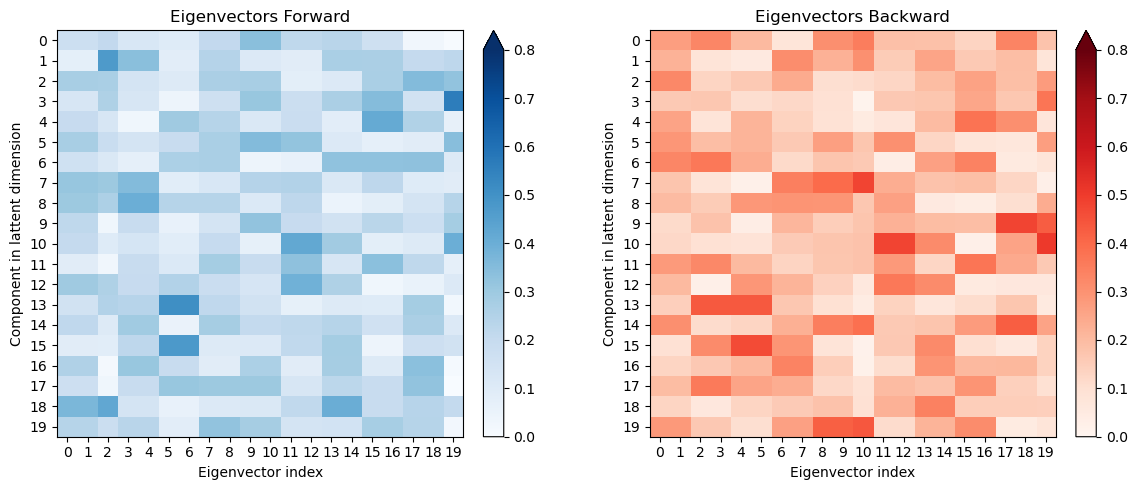

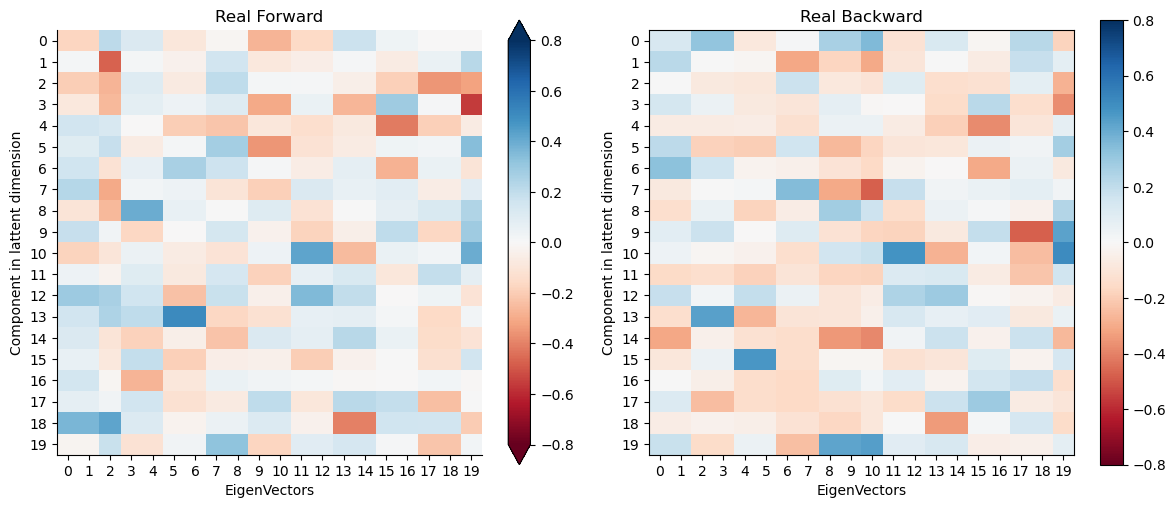

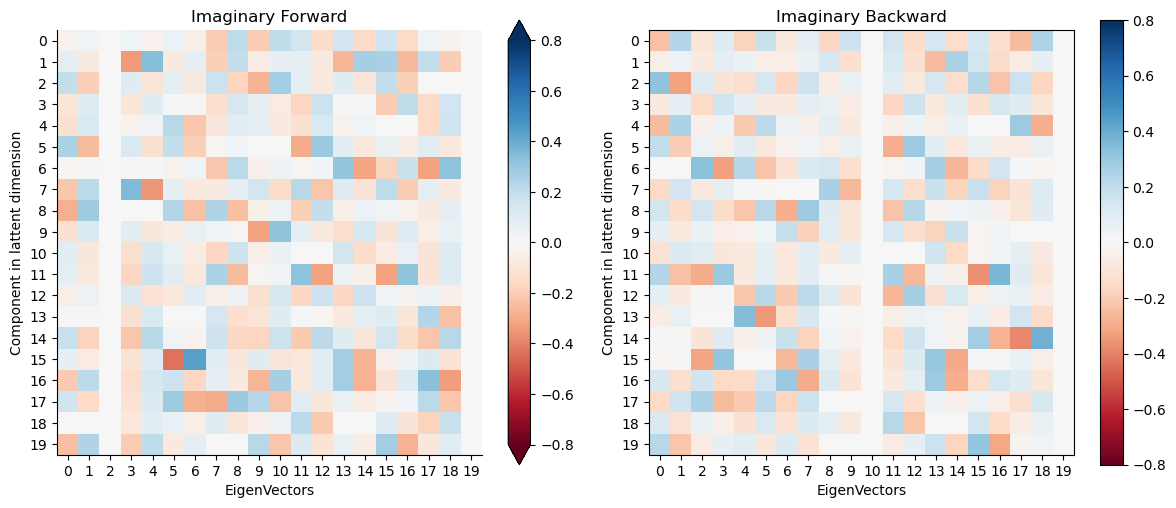

In [8]:
from scipy.ndimage import gaussian_filter1d


abs_vals = np.abs(eigenvectors)
real_vals = eigenvectors.real
imag_vals = eigenvectors.imag
abs_vals_b = np.abs(eigenvectors_b)
real_vals_b = eigenvectors_b.real
imag_vals_b = eigenvectors_b.imag

n_rows, n_cols = eigenvectors.shape

# Cria labels com parte real + imaginária para os autovalores
eigenvalues_str = [f"{val.real:.3f}{val.imag:+.3f}j" for val in eigenvalues]
eigenvalues_str_b = [f"{val.real:.3f}{val.imag:+.3f}j" for val in eigenvalues_b]

# === Plot 1: Módulo ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# Parte forward
im0 = axs[0].imshow(abs_vals, cmap='Blues', aspect='equal', vmin=0.0, vmax=0.8)
cbar = plt.colorbar(im0, ax=axs[0], extend='max', fraction=0.046, pad=0.04)
axs[0].set_title('Eigenvectors Forward')
axs[0].set_ylabel('Component in lattent dimension')
axs[0].set_xlabel('Eigenvector index')
axs[0].set_xticks(np.arange(n_cols))
axs[0].set_yticks(np.arange(n_rows))
#axs[0].set_yticklabels(eigenvalues_str)
# Backward
im0 = axs[1].imshow(abs_vals_b, cmap='Reds', aspect='equal', vmin=0.0, vmax=0.8)
cbar = plt.colorbar(im0, ax=axs[1], extend='max', fraction=0.046, pad=0.04)
axs[1].set_title('Eigenvectors Backward')
axs[1].set_ylabel('Component in lattent dimension')
axs[1].set_xlabel('Eigenvector index')
axs[1].set_xticks(np.arange(n_cols))
axs[1].set_yticks(np.arange(n_rows))
#axs[1].set_yticklabels(eigenvalues_str_b)

plt.tight_layout()
plt.show()

# === Plots 2: Real ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Forward
# Suaviza apenas no eixo Y (axis=0), sem mudar a shape
data_smooth_y = gaussian_filter1d(real_vals, sigma=1, axis=0)

im0 = axs[0].imshow(real_vals,
                    cmap='RdBu',
                    vmin=-0.8, vmax=0.8,
                    aspect='equal',
                    interpolation='nearest'  # mantém cada valor bem centrado
                    )
axs[0].set_title('Real Forward')
axs[0].set_ylabel('Component in lattent dimension')
axs[0].set_xlabel('EigenVectors')
axs[0].set_xticks(np.arange(n_cols))
axs[0].set_yticks(np.arange(n_rows))
#axs[0].set_yticklabels(eigenvalues_str)
plt.colorbar(im0, ax=axs[0], extend='both')
# Backward
im1 = axs[1].imshow(real_vals_b, cmap='RdBu', aspect='equal', vmin=-0.8, vmax=0.8)
axs[1].set_title('Real Backward')
axs[1].set_ylabel('Component in lattent dimension')
axs[1].set_xlabel('EigenVectors')
axs[1].set_xticks(np.arange(n_cols))
axs[1].set_yticks(np.arange(n_rows))
#axs[1].set_yticklabels(eigenvalues_str_b)
plt.colorbar(im1, ax=axs[1])

axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
#axs[0].spines['left'].set_visible(False)
#axs[0].spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()


# === Plots 3: Imaginária ===
# Forward
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
im0 = axs[0].imshow(imag_vals, cmap='RdBu', aspect='equal', vmin=-0.8, vmax=0.8)
axs[0].set_title('Imaginary Forward')
axs[0].set_xlabel('EigenVectors')
axs[0].set_ylabel('Component in lattent dimension')
axs[0].set_xticks(np.arange(n_cols))
axs[0].set_yticks(np.arange(n_rows))
#axs[0].set_yticklabels(eigenvalues_str)
plt.colorbar(im0, ax=axs[0], extend='both')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

# Backward
im1 = axs[1].imshow(imag_vals_b, cmap='RdBu', aspect='equal', vmin=-0.8, vmax=0.8)
axs[1].set_title('Imaginary Backward')
axs[1].set_ylabel('Component in lattent dimension')
axs[1].set_xlabel('EigenVectors')
axs[1].set_xticks(np.arange(n_cols))
axs[1].set_yticks(np.arange(n_rows))
#axs[1].set_yticklabels(eigenvalues_str_b)
plt.colorbar(im1, ax=axs[1])

plt.tight_layout()
plt.show()


/tmp/ipykernel_779765/141159145.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm', n_colors)


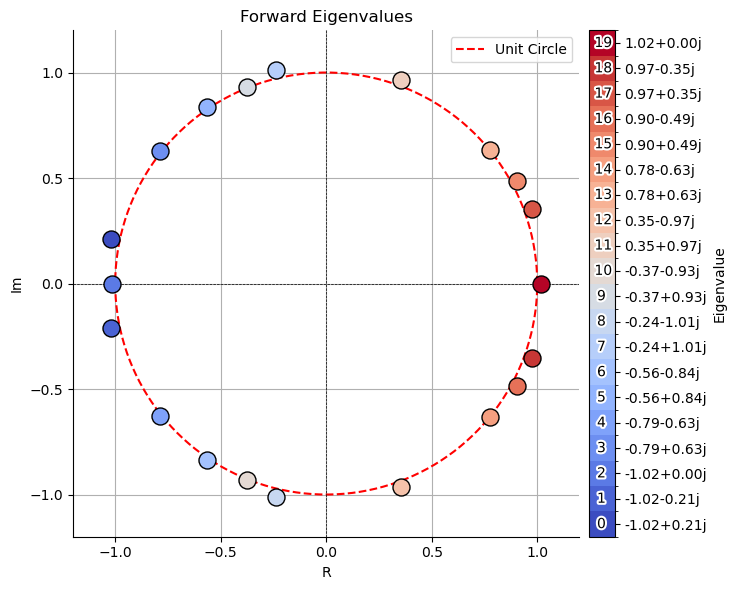

/tmp/ipykernel_779765/141159145.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm', n_colors)


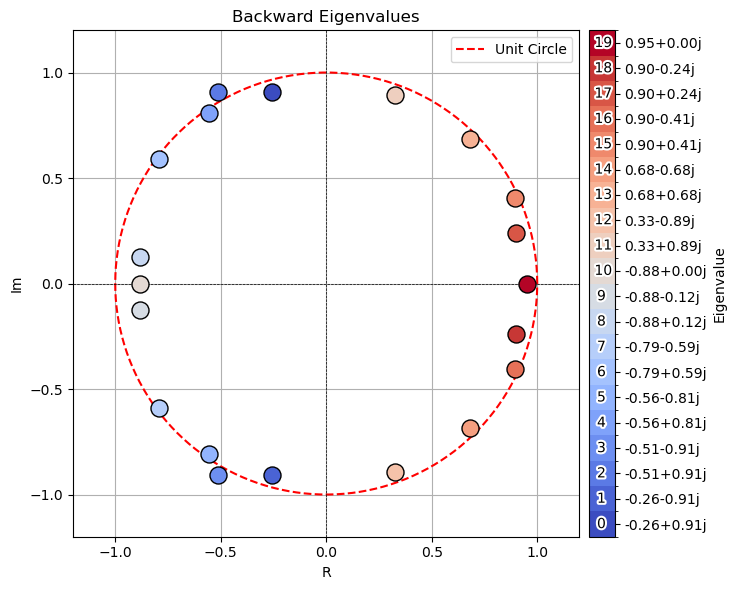

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import patheffects
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

real_parts = np.real(eigenvalues)
imag_parts = np.imag(eigenvalues)

# Círculo unitário
theta = np.linspace(0, 2 * np.pi, 500)
unit_circle_x = np.cos(theta)
unit_circle_y = np.sin(theta)

# Número de autovalores (20)
n_colors = len(eigenvalues)

# Cmap discreto com 20 tons
cmap = cm.get_cmap('coolwarm', n_colors)
colors = [cmap(i) for i in range(n_colors)]

plt.figure(figsize=(8, 6))

# Círculo unitário
plt.plot(unit_circle_x, unit_circle_y, color='red', linestyle='--', label='Unit Circle')

# Scatter dos autovalores coloridos
for i, (x, y) in enumerate(zip(real_parts, imag_parts)):
    plt.scatter(x, y, color=colors[i], edgecolor='black', s=150, zorder=3)

# Eixos e estética
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.title('Forward Eigenvalues')
plt.xlabel('R')
plt.ylabel('Im')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
# === Criar colorbar discreto com ticks 0 a 19 ===
# Faz um colormap discreto com os 20 tons
discrete_cmap = ListedColormap(colors)
bounds = np.arange(n_colors+1) - 0.5
norm = BoundaryNorm(bounds, discrete_cmap.N)

# Adiciona um eixo para colorbar (do lado direito)
from mpl_toolkits.axes_grid1 import make_axes_locatable
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.spines['left'].set_visible(False)
#ax.spines['bottom'].set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

# Colorbar discreta com ticks em 0..19
cb = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=discrete_cmap),
    cax=cax,
    ticks=np.arange(n_colors)
)
cb.set_label('Eigenvalue')
cb.ax.set_yticklabels([f"{val.real:.2f}{val.imag:+.2f}j" for val in eigenvalues])

for index_to_mark in range(len(eigenvalues)):
    x_placement = 0.3 if index_to_mark < 10 else 0.2

    text = cb.ax.text(  # ← assign it here!
        x_placement,                     # x-position
        index_to_mark,                   # y-position
        str(index_to_mark),             # text
        va='center', ha='left',
        fontsize=10, color='k',
        # fontweight='bold',
        # fontname='Times New Roman'
    )

    # Add white outline
    text.set_path_effects([
        patheffects.Stroke(linewidth=3, foreground='white'),  # white outline
        patheffects.Normal()
    ])

plt.tight_layout()
plt.show()

# BACKWARD

real_parts = np.real(eigenvalues_b)
imag_parts = np.imag(eigenvalues_b)

# Círculo unitário
theta = np.linspace(0, 2 * np.pi, 500)
unit_circle_x = np.cos(theta)
unit_circle_y = np.sin(theta)

# Número de autovalores (20)
n_colors = len(eigenvalues_b)

# Cmap discreto com 20 tons
cmap = cm.get_cmap('coolwarm', n_colors)
colors = [cmap(i) for i in range(n_colors)]

plt.figure(figsize=(8, 6))

# Círculo unitário
plt.plot(unit_circle_x, unit_circle_y, color='red', linestyle='--', label='Unit Circle')

# Scatter dos autovalores coloridos
for i, (x, y) in enumerate(zip(real_parts, imag_parts)):
    plt.scatter(x, y, color=colors[i], edgecolor='black', s=150, zorder=3)

# Eixos e estética
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.title('Backward Eigenvalues')
plt.xlabel('R')
plt.ylabel('Im')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
# === Criar colorbar discreto com ticks 0 a 19 ===
# Faz um colormap discreto com os 20 tons
discrete_cmap = ListedColormap(colors)
bounds = np.arange(n_colors+1) - 0.5
norm = BoundaryNorm(bounds, discrete_cmap.N)

# Adiciona um eixo para colorbar (do lado direito)
from mpl_toolkits.axes_grid1 import make_axes_locatable
ax = plt.gca()
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

# Colorbar discreta com ticks em 0..19
cb = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=discrete_cmap),
    cax=cax,
    ticks=np.arange(n_colors)
)
cb.set_label('Eigenvalue')
cb.ax.set_yticklabels([f"{val.real:.2f}{val.imag:+.2f}j" for val in eigenvalues_b])

for index_to_mark in range(len(eigenvalues_b)):
    x_placement = 0.3 if index_to_mark < 10 else 0.2

    text = cb.ax.text(  # ← assign it here!
        x_placement,                     # x-position
        index_to_mark,                   # y-position
        str(index_to_mark),             # text
        va='center', ha='left',
        fontsize=10, color='k',
        # fontweight='bold',
        # fontname='Times New Roman'
    )

    # Add white outline
    text.set_path_effects([
        patheffects.Stroke(linewidth=3, foreground='white'),  # white outline
        patheffects.Normal()
    ])

plt.tight_layout()
plt.show()

## Geostrofic Equilibrium ##

In [10]:
import time
import SWE, tools
importlib.reload(SWE)
importlib.reload(tools)
from SWE import *
from tools import SincNetwork
m_list    = [50   ,100 ,200 ,400 ] # [200 ] # 
dt_list   = [1440.,720.,360.,180.] # [360.] # 
ICs       = [2]
for m in model:
    m.eval()
Models    = [[None,None] ,[None,None]      ,model]               # [[None,None],model]                 # [[None,None] ,[None,None]      ,model]
equations = ['AB3AM4'   ,'swe'      ,'AB3AM4']                   # ['swe','AB3AM4']                    # ['AB3AM4'   ,'swe'      ,'AB3AM4']
Ns        = [[None,None,None],[None,None,None],Normalização]     # [[None,None,None],Normalização]     # [[None,None,None],[None,None,None],Normalização]
Nos       = [[None,None,None],[None,None,None],Normalização_out] # [[None,None,None],Normalização_out] # [[None,None,None],[None,None,None],Normalização_out]
# Desativa a exibição automática dos plots do sistema final
matplotlib.use('Agg')

for ini in ICs:
  tab       = PrettyTable(["Initial Condition","Model","Dx (km)", "Dt (min)",  "Erro u", "Erro v", "Erro h","Integration Time (s)"])

  for Model,N,No,equation in zip(Models,Ns,Nos,equations):
    
    #Model = 'AB3AM4'
    if Model[0] is None:
        print('#################### \n Integrating with equation',equation,'\n#####################')
        #continue
    else:
        print('#################### \n Integrating with LieAE \n#####################')
    for i in range(len(m_list)):
      m = m_list[i]
      dt = dt_list[i]
      if Model[0] != None:
          if Model[0].encoder[0].typeB:
      #       print (Model[0].encoder[0].bilinear2.weight)
      #        with torch.no_grad():
      #          Model[0].encoder[0].bilinear2.weight.fill_(0)
             SincNetwork(Model[0].encoder[0],dt)
      #       print('after', Model[0].encoder[0].bilinear2.weight)
        
      # Discrete domain construction
      T= oneday # 12*oneday
        
      # Shallow water 2D problem
      unflip_domain = True # needs to be unfliped fpr the manual AB3AM4 algorithm
      # DOMAIN
      X = np.pi*erad
      dom = Domain2D(t0=0.0, T=T, xi=-X, xf=X, yi=-X,
                     yf=X, dt=dt, mx=m, my=m,CROCO=unflip_domain)
      
      hbar = 10000
      f = 2.0*omega
      noise_amp = 0 # 1e-6 * hbar
      if equation == 'swe': # the rk3 integration does not work with the new Topography definition.
          sw  = SWE_2D(hbar = hbar, f = f, g = grav, ini = ini, dom = dom,
                   random=False,noise_amp=noise_amp,Topo = 0)
      else:
          sw  = SWE_2D(hbar = 0, f = f, g = grav, ini = ini, dom = dom,
                       random=False,noise_amp=noise_amp,Topo = hbar)
      
      num_met  = SWE_2D_num_method(dom = dom, sw = sw, equation = equation)

      plot_ktimes = [-1]
      # Iniciar cronômetro
      inicio = time.perf_counter()
      u, v, h = time_int(num_met, plot_ktimes,Model,N,No)
      # Finalizar cronômetro
      fim = time.perf_counter()
      int_time = f"{fim-inicio:.3f}"
      
      er_u = np.max(np.abs(u-sw.u0()))
      er_v = np.max(np.abs(v-sw.v0()))
      er_h = np.max(np.abs(h-sw.h0()))
      if Model[0] is None:
        tab.add_row([ini,equation,m/1000, dt/60, f"{er_u:.5f}", f"{er_v:.5f}", f"{er_h:.5f}", int_time ])
      else:
        tab.add_row([ini,'LieAE' ,m/1000, dt/60, f"{er_u:.5f}", f"{er_v:.5f}", f"{er_h:.5f}", int_time ])
        
  print(tab)    

Gravity wave Courant number
0.033188167252486446
#################### 
 Integrating with equation AB3AM4 
#####################
Calculating dx based on given mx. dx =  800631.1178561744
Calculating dy based on given my. dy =  800631.1178561744
Gravity wave Courant number
0.0
código modificado para AB3-AM4
 
 Time final iteration k= 60  corresponds to time =  1.0  days


/home/iuri/KoopmanAE/SWE.py:815: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


Calculating dx based on given mx. dx =  400315.5589280872
Calculating dy based on given my. dy =  400315.5589280872
Gravity wave Courant number
0.0
código modificado para AB3-AM4
 
 Time final iteration k= 120  corresponds to time =  1.0  days
Calculating dx based on given mx. dx =  200157.7794640436
Calculating dy based on given my. dy =  200157.7794640436
Gravity wave Courant number
0.0
código modificado para AB3-AM4
 
 Time final iteration k= 240  corresponds to time =  1.0  days
Calculating dx based on given mx. dx =  100078.8897320218
Calculating dy based on given my. dy =  100078.8897320218
Gravity wave Courant number
0.0
código modificado para AB3-AM4
 
 Time final iteration k= 480  corresponds to time =  1.0  days
#################### 
 Integrating with equation swe 
#####################
Calculating dx based on given mx. dx =  800631.1178561744
Calculating dy based on given my. dy =  800631.1178561744
Gravity wave Courant number
0.3982580070298374
código modificado para AB3-AM

## Perturbation ##

In [ ]:
#%%capture
import SWE, tools
importlib.reload(SWE)
importlib.reload(tools)
from SWE import *
from tools import *
# Discrete domain construction
parameter = .5

T=20*oneday#/parameter
# Shallow water 2D problem
unflip_domain = True # needs to be unfliped fpr the manual AB3AM4 algorithm
equation = "AB3AM4" # 'swe'

# DOMAIN
X = np.pi*erad
DT,XY = 360/parameter,200*parameter
dom = Domain2D(t0=0.0, T=T, xi=-X, xf=X, yi=-X,
               yf=X, dt=DT, mx=XY, my=XY,CROCO=unflip_domain)

# Unstable Jet #
hbar = 10000
f = 2.0*omega
noise_amp = 1e-6 * hbar
sw  = SWE_2D(hbar = 0, f = f, g = grav, ini = 3, dom = dom,
             random=False,noise_amp=noise_amp,Topo = hbar)

# Gaussian Tsunami #
#hbar = 100 #      # ini=5
#f = 0             # ini=5
#DT,XY = 720,100   # ini = 5
#dom = Domain2D(t0=0.0, T=T, xi=-X, xf=X, yi=-X,
#               yf=X, dt=DT, mx=XY, my=XY,CROCO=unflip_domain)
#sw  = SWE_2D(hbar = hbar, f = f, g = grav, ini = 5, dom = dom,
#             random=True,noise_amp=noise_amp,Topo = 0)

# Numerical method and operators
num_met  = SWE_2D_num_method(dom = dom, sw = sw, equation = equation)

In [ ]:
# AB3-AM4 Foward Intergration
num_plots = 3 # 12 days - 60 / 20 days - 200 / 36 days - 400
plot_ktimes = (np.arange(num_plots)/num_plots)*dom.nt+2
#print(plot_ktimes, dom.nt)
U2,V2,H2 = time_int(num_met, plot_ktimes,mode='forward',save_int=True)

In [ ]:
# FORWARD INTEGRATION WITH NETWORK - USING DELTA>0 FOR STOCHASTIC ANALYSIS
U2NN1,V2NN1,H2NN1 = time_int(num_met, plot_ktimes,model,Normalização,Normalização_out,save_int=True)
#U2NN2,V2NN2,H2NN2 = time_int(num_met, plot_ktimes,model,Normalização,Normalização_out,save_int=True)
#U2NN3,V2NN3,H2NN3 = time_int(num_met, plot_ktimes,model,Normalização,Normalização_out,save_int=True)
#U2NN4,V2NN4,H2NN4 = time_int(num_met, plot_ktimes,model,Normalização,Normalização_out,save_int=True)
#U2NN5,V2NN5,H2NN5 = time_int(num_met, plot_ktimes,model,Normalização,Normalização_out,save_int=True)

### Print Static states

In [ ]:
import tools
importlib.reload(tools)
from tools import *

In [ ]:
## Zeta and Vorticity PLOTS ## 
counter = 0
SAVE=False
# Cria vetores de 1 até 200 (inclusive)
lat = np.arange(0, H2[0].shape[0])
lon = np.arange(0, H2[0].shape[1])
plot1 = [None,None]
plot2 = [None,None]

for h2,u2,v2,h2NN,u2NN,v2NN,time in zip(H2,U2,V2,H2NN1,U2NN1,V2NN1,plot_ktimes):
    plot1[0]= h2
    plot2[0]= h2NN
    plot1[1] = num_met.rel_vort(u2,v2)
    plot2[1] = num_met.rel_vort(u2NN,v2NN)
    print('Plotting step',time)
    diretorio = '/home/iuri/CROCO/Diagnostics/Figures'
    if not os.path.isdir(diretorio):
        os.mkdir(diretorio)
    if counter < 10:
         N=str(0)+str(0)+str(0)+str(0)+str(counter)
    elif counter < 100:
         N=str(0)+str(0)+str(0)+str(counter)
    elif counter < 1000:
         N=str(0)+str(0)+str(counter)
    elif counter < 10000:
         N=str(0)+str(counter)
    else:
         N=str(i)
    nome_arquivo = 'System'+N+'.png'
    caminho_final = os.path.join(diretorio, nome_arquivo)
    
    if counter == 0:
        MAXIMO     = (np.max(plot1[0]))
        MINIMO     = (np.min(plot1[0]))
        MAXIMO_tar = (np.max(plot2[0]))
        MINIMO_tar = (np.min(plot2[0]))
        limite = np.max([MAXIMO,-MINIMO,MAXIMO_tar,-MINIMO_tar])
        levels1 = np.linspace(-limite*1.2, limite*1.2, 50)
        levels1 = np.linspace(-550, 1300, 50)
    if counter == 0:
        MAXIMO     = (np.max(plot1[1]))
        MINIMO     = (np.min(plot1[1]))
        MAXIMO_tar = (np.max(plot2[1]))
        MINIMO_tar = (np.min(plot2[1]))
        limite = np.max([MAXIMO,-MINIMO,MAXIMO_tar,-MINIMO_tar])
        levels2 = np.linspace(-8e-5, 8e-5, 50)
        
    counter +=1
    plot3 = [None] * len(plot1)
    for i in range(len(plot1)):
        plot3[i]  = plot2[i]-plot1[i]
    levels = [levels1,levels2]
    
    Bias_Plot(lat,lon,plot1,plot2,plot3,
              levels=levels,save=SAVE,
              folder=caminho_final,dominio='abstract',Energy=False)

### GIF

In [ ]:
import glob
from PIL import Image

def make_gif(folder,save_name,save_folder,duration=10):
    # cria gif apartir de imagens jpg ou png arquivadas em 'folder' #
    # salva o gif no 'save_folder' com o nome 'save_name'          #
    
    frames = [Image.open(image) for image in sorted(glob.glob(f"{folder}/*.png"))]
    print('fazendo gif com ',len(frames), 'frames de duração ',duration)
    frame_one = frames[0]
    frame_one.save(save_folder+save_name+".gif", format="GIF", append_images=frames,
               save_all=True, duration=duration, loop=0)

In [20]:
# Save figures for gif #

## Zeta and Vorticity PLOTS ## 
# Cria vetores de 1 até 200 (inclusive)
first = True
lat = np.arange(1, 201)
lon = np.arange(1, 201)
plot1 = [None,None]
CC = -1
for HS,US,VS,names in zip([[H2,H2NN1],[H2NN2,H2NN3],[H2NN4,H2NN5]],
                          [[U2,U2NN1],[U2NN2,U2NN3],[U2NN4,U2NN5]],
                          [[V2,V2NN1],[V2NN2,V2NN3],[V2NN4,V2NN5]],
                          [['AB3AM4','LieAE1'],['LieAE2','LieAE3'],['LieAE4','LieAE5']]): # zip([H2,H2NN1],[U2,U2NN1],[V2,V2NN1]):
 CC +=1
 for H,U,V,name in zip(HS,US,VS,names): #['Truth','LieAE']
    counter = 0
    #if CC > 0:
    # break # apenas ajeitando o ColorBar do plot #
    for h2,u2,v2,time in zip(H,U,V,plot_ktimes):
        #if CC > 0:
        # break # apenas ajeitando o ColorBar do plot #
        plot1[0]= h2
        plot1[1] = num_met.rel_vort(u2,v2)
        diretorio = '/home/iuri/CROCO/Diagnostics/Gif_SWE/'+name+'_delta'
        if not os.path.isdir(diretorio):
                os.mkdir(diretorio)
        if counter < 10:
             N=str(0)+str(0)+str(0)+str(0)+str(counter)
        elif counter < 100:
             N=str(0)+str(0)+str(0)+str(counter)
        elif counter < 1000:
             N=str(0)+str(0)+str(counter)
        elif counter < 10000:
             N=str(0)+str(counter)
        else:
             N=str(i)
        nome_arquivo = N+'.png'
        caminho_final = os.path.join(diretorio, nome_arquivo)
        
        if first:
            levels1 = np.linspace(-500, 1300, 50)
            levels2 = np.linspace(-8e-5, 8e-5, 50)
            first = False
            
        counter +=1
        levels = [levels1,levels2]
        
        One_Plot(lat,lon,plot1,
                  levels=levels,save=True,
                  folder=caminho_final,dominio='abstract',Energy=False)
        

In [ ]:
## Bias PLOTS ## 
counter = 0
# Cria vetores de 1 até 200 (inclusive)
lat = np.arange(1, 201)
lon = np.arange(1, 201)
plot1 = [None,None]
plot2 = [None,None]
C=-1
for H,U,V,HNN,UNN,VNN,Name in zip([H2,H2NN2,H2NN3,H2NN2,H2NN2],
                                  [U2,U2NN2,U2NN3,U2NN2,U2NN2],
                                  [V2,V2NN2,V2NN3,V2NN2,V2NN2],
                                  [H2NN1,H2NN1,H2NN1,H2NN4,H2NN5],
                                  [U2NN1,U2NN1,U2NN1,U2NN4,U2NN5],
                                  [V2NN1,V2NN1,V2NN1,V2NN4,V2NN5],
                                  ['AB3AM4_Lie1','Lie2_Lie1','Lie3_lie1','Lie2_lie4','Lie2_lie5']):
 counter = 0
 C+=1
 levels1 = np.linspace(-1300, 1300, 50)
 levels2 = np.linspace(-8e-5, 8e-5, 50)

 for h2,u2,v2,h2NN,u2NN,v2NN,time in zip(H,U,V,HNN,UNN,VNN,plot_ktimes):
    plot1[0]= h2
    plot2[0]= h2NN
    plot1[1] = num_met.rel_vort(u2,v2)
    plot2[1] = num_met.rel_vort(u2NN,v2NN)
    diretorio = '/home/iuri/CROCO/Diagnostics/Gif_SWE/Bias'+Name
    if not os.path.isdir(diretorio):
        os.mkdir(diretorio)
    if counter < 10:
         N=str(0)+str(0)+str(0)+str(0)+str(counter)
    elif counter < 100:
         N=str(0)+str(0)+str(0)+str(counter)
    elif counter < 1000:
         N=str(0)+str(0)+str(counter)
    elif counter < 10000:
         N=str(0)+str(counter)
    else:
         N=str(i)
    nome_arquivo = N+'.png'
    caminho_final = os.path.join(diretorio, nome_arquivo)
    
    counter +=1
    plot3 = [None] * len(plot1)
    for i in range(len(plot1)):
        plot3[i]  = plot2[i]-plot1[i]
    levels = [levels1,levels2]
    
    One_Plot(lat,lon,plot3,
              levels=levels,save=True,
              folder=caminho_final,dominio='abstract',Energy=False)

In [23]:
# FAZ GIF COM FIGURAS .jpg
for save_name in ['AB3AM4_delta','LieAE1_delta','LieAE2_delta',
                  'LieAE3_delta','LieAE4_delta','LieAE5_delta']: #['Truth','LieAE','Bias']
    folder = '/home/iuri/CROCO/Diagnostics/Gif_SWE/'+save_name+'/'
    save_folder = '/home/iuri/CROCO/Diagnostics/Gif_SWE/'
    
    print('fazendo gif')
    # folder é onde as figuras .jpg foram salvas
    make_gif(folder,save_name,save_folder,duration=60)
    print('gif feito')

fazendo gif
fazendo gif com  176 frames de duração  60
gif feito
fazendo gif
fazendo gif com  176 frames de duração  60
gif feito
fazendo gif
fazendo gif com  176 frames de duração  60
gif feito
